# Projeto Final – Mineração de Dados

## Predição da Energia de Docking de Peptídeos utilizando Aprendizado de Máquina

Este projeto tem como objetivo reproduzir parte do framework SAGAPEP, desenvolvido na Universidade Federal de Uberlândia (UFU), utilizando técnicas clássicas de Mineração de Dados.

Enquanto o SAGAPEP completo combina modelos preditivos com Algoritmos Genéticos para descoberta automática de novos peptídeos, neste projeto o foco será exclusivamente na construção e avaliação de modelos de Aprendizado de Máquina capazes de predizer a energia de docking de peptídeos a partir de suas sequências de aminoácidos.

O projeto seguirá todas as etapas clássicas do processo de KDD(Knowledge Discovery in Databases):

• Compreensão dos dados

• Pré-processamento

• Engenharia de atributos

• Modelagem

• Avaliação

• Interpretação dos resultados

## Objetivos deste notebook

Neste notebook serão realizadas as primeiras etapas do processo de Mineração de Dados:

- conhecer o conjunto de dados;

- verificar sua qualidade;

- identificar inconsistências;

- realizar análises estatísticas;

- produzir visualizações;

- compreender o comportamento da variável resposta.

In [34]:
# ============================================================
# Bibliotecas para manipulação dos dados
# ============================================================

import pandas as pd
import numpy as np

# ============================================================
# Bibliotecas para visualização
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Configuração gráfica
# ============================================================

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10,6)

# ============================================================
# Estatística
# ============================================================

from scipy import stats

# ============================================================
# Configuração do Pandas
# ============================================================

pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",100)

print("Bibliotecas carregadas.")

Bibliotecas carregadas.


In [35]:
df = pd.read_csv("../data/raw/sagapep.csv")

df.head()

,peptide_fasta_sequence,best_docking_score
0,RFGYGYGPY,-230.308
1,PAAAPPTLPPYFMKGSIIQLANGELKKV,-227.293
2,SIPPCPQTWRSLWIGYSFLMHTG,-224.630
3,RIGRFGYGYGPY,-218.979
4,PGPRYQPFRLT,-218.227


Cada linha representa um peptídeo.

Cada peptídeo possui

• sequência

• energia de docking


In [36]:
print(df.shape)

df.info()

(296, 2)
<class 'pandas.DataFrame'>
RangeIndex: 296 entries, 0 to 295
Data columns (total 2 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   peptide_fasta_sequence  296 non-null    str    
 1   best_docking_score      296 non-null    float64
dtypes: float64(1), str(1)
memory usage: 4.8 KB


In [37]:
df.sample(10)

,peptide_fasta_sequence,best_docking_score
267,SSSGPSIKDKYV,-180.209
3,RIGRFGYGYGPY,-218.979
4,PGPRYQPFRLT,-218.227
243,NCAIPKGLKYNQAT,-179.160
125,PPSPAQPPPGVSP,-171.113
80,PGPVGSPGLPGAIGTDGTPGPKGP,-181.982
169,GPGRIPPPPP,-156.863
76,HDERQDSINAYNE,-183.433
102,PFIAIHAESKL,-176.910
124,CIEMGLGMIKA,-171.453


## Estrutura do conjunto de dados

Após o carregamento da base, podemos observar que cada linha representa um **peptídeo** avaliado por meio de simulações de **docking molecular** contra a proteína Spike do SARS-CoV-2.

A base utilizada neste projeto é composta por duas colunas, que representam, respectivamente, a sequência de aminoácidos do peptídeo e sua energia de interação com a proteína-alvo.

A seguir são descritos os atributos disponíveis.

| Coluna | Tipo | Descrição |
|---------|------|-----------|
| **peptide_fasta_sequence** | Texto | Sequência do peptídeo representada pelo código de uma letra para cada aminoácido, seguindo o padrão FASTA. Cada caractere corresponde a um dos 20 aminoácidos naturais presentes nas proteínas. |
| **best_docking_score** | Numérico | Melhor energia de docking (kcal/mol) obtida para o peptídeo durante a simulação computacional de interação com a proteína Spike. Essa será a variável alvo (target) utilizada pelos modelos de Aprendizado de Máquina. |

### Exemplo de registros

| peptide_fasta_sequence | best_docking_score |
|-------------------------|------------------:|
| PKVKMALRTSGHL | -177.914 |
| GLGFDPEMQ | -164.233 |
| PQTPLSTTGYLHTTPA | -202.362 |
| ISSQLDKASIVRLSVTY | -158.362 |
| IIITSLSDQIMEDSP | -151.936 |

### Atributo `peptide_fasta_sequence`

A coluna **`peptide_fasta_sequence`** contém a sequência linear de aminoácidos que compõem cada peptídeo. Cada letra representa um aminoácido específico segundo a nomenclatura internacional de uma letra.

Por exemplo, a sequência:

```
PKVKMALRTSGHL
```

pode ser interpretada como:

| Símbolo | Aminoácido |
|----------|------------|
| P | Prolina (Proline) |
| K | Lisina (Lysine) |
| V | Valina (Valine) |
| M | Metionina (Methionine) |
| A | Alanina (Alanine) |
| L | Leucina (Leucine) |
| R | Arginina (Arginine) |
| T | Treonina (Threonine) |
| S | Serina (Serine) |
| G | Glicina (Glycine) |
| H | Histidina (Histidine) |

Essas sequências constituem a informação biológica utilizada para gerar os descritores (AAC, AAL, CKSNAP e CKSAAGP) que serão empregados na construção dos modelos preditivos.

### Atributo `best_docking_score`

A coluna **`best_docking_score`** representa a melhor energia de interação obtida entre o peptídeo e a proteína Spike durante as simulações de docking molecular.

Essa variável será utilizada como **variável resposta (target)** no problema de regressão.

Em docking molecular, valores mais negativos indicam uma interação potencialmente mais forte entre o peptídeo e a proteína-alvo.

Por exemplo:

- **−230 kcal/mol** → interação muito forte;
- **−200 kcal/mol** → interação forte;
- **−170 kcal/mol** → interação moderada;
- **−150 kcal/mol** → interação relativamente fraca.

Portanto, o objetivo dos modelos de Aprendizado de Máquina será aprender a relação entre a sequência do peptídeo (representada posteriormente pelos descritores) e sua energia de docking, permitindo estimar esse valor para novos peptídeos sem a necessidade de executar novamente o processo computacional de docking, que possui elevado custo computacional.

### Observação importante

Embora o conjunto de dados possua apenas duas colunas, ele **não é um conjunto de baixa dimensionalidade**. A coluna `peptide_fasta_sequence` contém informação biológica rica, que será transformada em centenas de atributos numéricos durante a etapa de engenharia de características. Assim, cada sequência deixará de ser representada como um texto e passará a ser descrita por vetores de características capazes de capturar propriedades de composição, ordem e relações entre aminoácidos, permitindo a aplicação de algoritmos clássicos de Mineração de Dados.

In [38]:
df.isnull().sum()

peptide_fasta_sequence    0
best_docking_score        0
dtype: int64

In [39]:
df.duplicated().sum()

np.int64(1)

In [40]:
df["peptide_fasta_sequence"].nunique()

295

In [41]:
df["best_docking_score"].value_counts()

best_docking_score
-177.641    2
-167.378    2
-164.226    2
-170.383    2
-230.308    1
           ..
-149.184    1
-167.486    1
-169.224    1
-160.745    1
-170.340    1
Name: count, Length: 292, dtype: int64

In [42]:
df.describe()

,best_docking_score
count,296.000000
mean,-175.975973
std,19.344383
min,-230.308000
25%,-188.397500
50%,-176.110000
75%,-161.615000
max,-126.060000


In [43]:
df.describe(include="all")

,peptide_fasta_sequence,best_docking_score
count,296,296.000000
unique,295,NaN
top,QGVNDNEEGFFSAR,NaN
freq,2,NaN
mean,NaN,-175.975973
std,NaN,19.344383
min,NaN,-230.308000
25%,NaN,-188.397500
50%,NaN,-176.110000
75%,NaN,-161.615000


## Estatística descritiva da variável alvo

Uma das primeiras etapas da Análise Exploratória de Dados (EDA) consiste em compreender o comportamento da variável que será prevista pelos modelos de Aprendizado de Máquina.

Neste projeto, a variável resposta é **`best_docking_score`**, que representa a melhor energia de interação entre um peptídeo e a proteína Spike do SARS-CoV-2 obtida por meio de simulações de docking molecular.

A tabela abaixo apresenta um resumo estatístico dessa variável.

| Estatística | Valor |
|-------------|-------:|
| Número de amostras | 296 |
| Média | -175,98 |
| Desvio padrão | 19,34 |
| Valor mínimo | -230,31 |
| 1º Quartil (Q1) | -188,40 |
| Mediana | -176,11 |
| 3º Quartil (Q3) | -161,62 |
| Valor máximo | -126,06 |

### Média

A média das energias de docking é **-175,98 kcal/mol**.

Esse valor representa a energia média de interação entre todos os peptídeos presentes na base de dados.

Como energias mais negativas indicam interações mais fortes entre o peptídeo e a proteína-alvo, pode-se dizer que, em média, os peptídeos apresentam uma afinidade intermediária com a proteína Spike.

A média também servirá como referência para avaliar o desempenho dos modelos de regressão durante as etapas posteriores do projeto.

---

### Mediana

A mediana é **-176,11 kcal/mol**.

Esse valor divide o conjunto de dados exatamente ao meio:

- 50% dos peptídeos apresentam energia inferior (mais negativa) que -176,11 kcal/mol;
- 50% apresentam energia superior (menos negativa).

Observa-se que a mediana é extremamente próxima da média (-175,98 kcal/mol), indicando que a distribuição da variável resposta tende a ser relativamente simétrica, sem grandes distorções provocadas por valores extremos.

---

### Quartis

Os quartis dividem o conjunto de dados em quatro partes iguais.

Neste conjunto de dados temos:

- **Q1 = -188,40 kcal/mol**
- **Q2 = -176,11 kcal/mol** (mediana)
- **Q3 = -161,62 kcal/mol**

Isso significa que:

- aproximadamente **25% dos peptídeos** possuem energia menor que **-188,40 kcal/mol**, correspondendo aos candidatos com maior afinidade molecular;

- aproximadamente **50%** encontram-se entre **-188,40** e **-161,62 kcal/mol**;

- os **25% restantes** possuem energias superiores a **-161,62 kcal/mol**, indicando interações relativamente mais fracas.

Os quartis também serão importantes para identificar possíveis valores atípicos (outliers) através de boxplots nas próximas análises.

---

### Desvio padrão

O desvio padrão é igual a **19,34 kcal/mol**.

Essa medida indica o quanto os valores se afastam, em média, da média da distribuição.

Um desvio padrão dessa magnitude mostra que existe uma variabilidade considerável entre os peptídeos da base.

Essa diversidade é desejável em problemas de Aprendizado de Máquina, pois fornece exemplos suficientemente distintos para que os algoritmos consigam aprender padrões relevantes entre as características dos peptídeos e sua energia de docking.

---

### Amplitude

A amplitude corresponde à diferença entre o maior e o menor valor observado.

Neste conjunto de dados:

- Valor mínimo = **-230,31 kcal/mol**
- Valor máximo = **-126,06 kcal/mol**

Portanto,

\[
\text{Amplitude} = -126,06 - (-230,31) = 104,25 \text{ kcal/mol}
\]

Uma amplitude superior a **100 kcal/mol** evidencia que a base contém peptídeos com níveis bastante distintos de afinidade molecular.

Essa grande variação é importante para o treinamento dos modelos de regressão, pois amplia a capacidade de generalização dos algoritmos ao contemplar exemplos com diferentes níveis de interação.

---

## Conclusões

A análise estatística inicial permite concluir que:

- a base possui **296 peptídeos**, número adequado para experimentos de regressão em um contexto acadêmico;
- a variável resposta apresenta distribuição relativamente equilibrada, uma vez que média e mediana possuem valores muito próximos;
- existe boa variabilidade na energia de docking (desvio padrão de aproximadamente **19 kcal/mol**);
- a amplitude superior a **100 kcal/mol** indica a presença de peptídeos com afinidades bastante distintas;
- praticamente todas as sequências são exclusivas, evidenciando diversidade estrutural no conjunto de dados.

Esses resultados sugerem que a base possui qualidade suficiente para prosseguir com as etapas de engenharia de atributos e construção dos modelos preditivos que serão desenvolvidos nos próximos notebooks.

In [44]:
#Comprimento
df["length"] = df["peptide_fasta_sequence"].str.len()

#Número de aminoácidos distintos
df["unique_aminoacids"] = (
    df["peptide_fasta_sequence"]
    .apply(lambda x: len(set(x)))
)

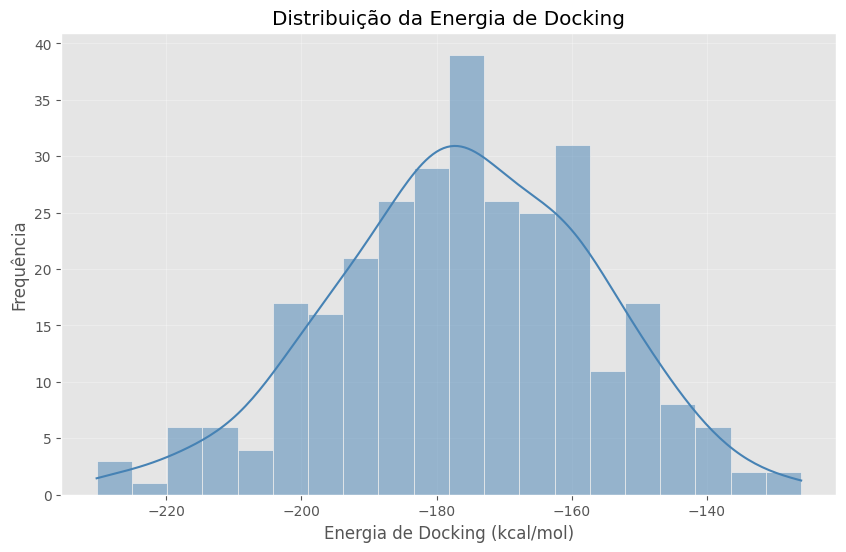

In [45]:
# ============================================================
# Histograma da energia de docking
# ============================================================

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="best_docking_score",
    bins=20,
    kde=True,
    color="steelblue"
)

plt.title("Distribuição da Energia de Docking")
plt.xlabel("Energia de Docking (kcal/mol)")
plt.ylabel("Frequência")

plt.grid(alpha=0.3)

plt.show()

Interpretação esperada

distribuição aproximadamente normal?

existe assimetria?

existem múltiplos picos (multimodalidade)?

concentração de valores?

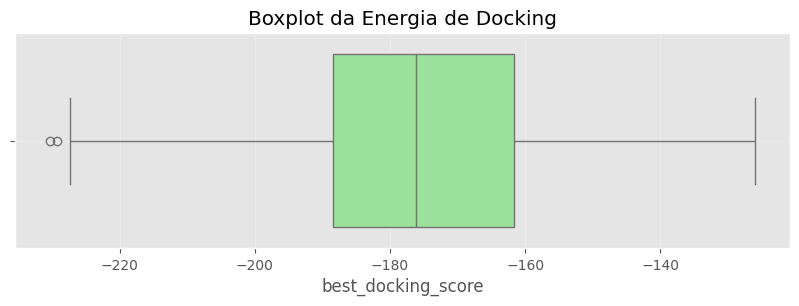

In [46]:
# ============================================================
# Boxplot da energia de docking
# ============================================================

plt.figure(figsize=(10,2.8))

sns.boxplot(
    x=df["best_docking_score"],
    color="lightgreen"
)

plt.title("Boxplot da Energia de Docking")

plt.grid(alpha=0.3)

plt.show()

Interpretar

valores extremos

assimetria

posição da mediana

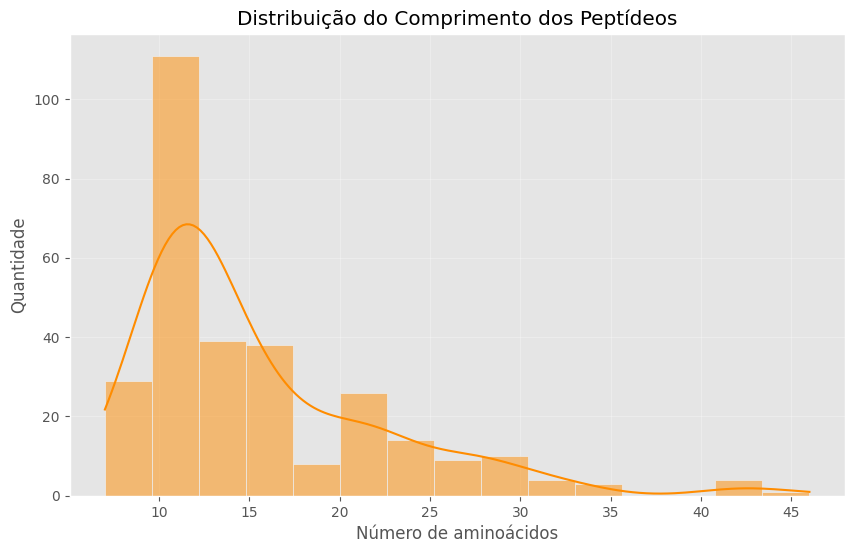

In [47]:
# ============================================================
# Histograma do comprimento dos peptídeos
# ============================================================

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="length",
    bins=15,
    kde=True,
    color="darkorange"
)

plt.title("Distribuição do Comprimento dos Peptídeos")

plt.xlabel("Número de aminoácidos")

plt.ylabel("Quantidade")

plt.grid(alpha=0.3)

plt.show()

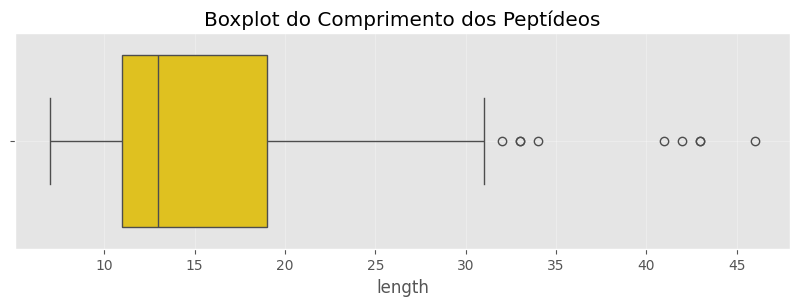

In [48]:
# ============================================================
# Boxplot do comprimento
# ============================================================

plt.figure(figsize=(10,2.8))

sns.boxplot(
    x=df["length"],
    color="gold"
)

plt.title("Boxplot do Comprimento dos Peptídeos")

plt.grid(alpha=0.3)

plt.show()

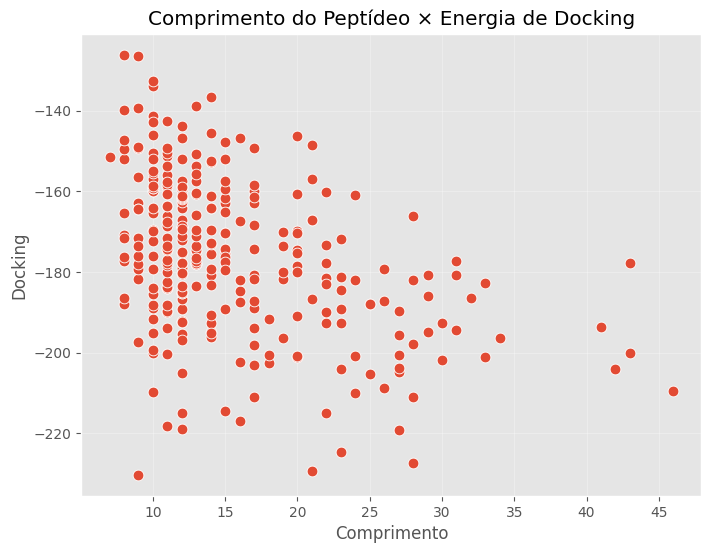

In [49]:
# ============================================================
# Relação entre comprimento e energia de docking
# ============================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="length",
    y="best_docking_score",
    s=60
)

plt.title("Comprimento do Peptídeo × Energia de Docking")

plt.xlabel("Comprimento")

plt.ylabel("Docking")

plt.grid(alpha=0.3)

plt.show()

In [50]:
print(df[["length","best_docking_score"]].corr())

                      length  best_docking_score
length              1.000000           -0.422205
best_docking_score -0.422205            1.000000


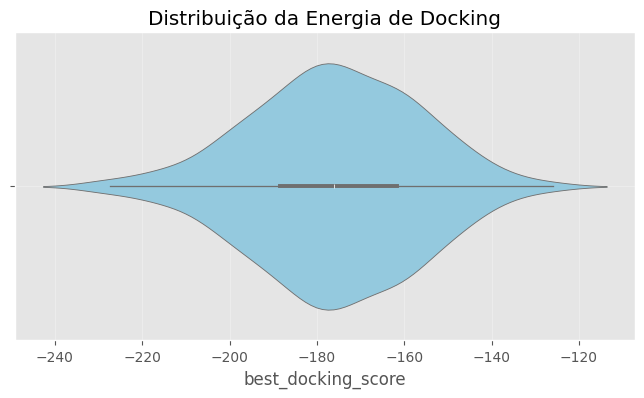

In [51]:
# ============================================================
# Violin Plot
# ============================================================

plt.figure(figsize=(8,4))

sns.violinplot(
    x=df["best_docking_score"],
    color="skyblue"
)

plt.title("Distribuição da Energia de Docking")

plt.grid(alpha=0.3)

plt.show()

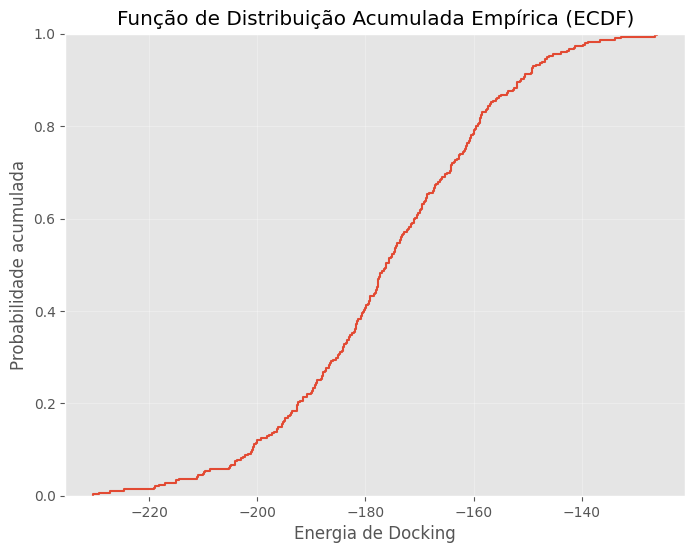

In [52]:
# ============================================================
# ECDF
# ============================================================

plt.figure(figsize=(8,6))

sns.ecdfplot(
    data=df,
    x="best_docking_score"
)

plt.title("Função de Distribuição Acumulada Empírica (ECDF)")

plt.xlabel("Energia de Docking")

plt.ylabel("Probabilidade acumulada")

plt.grid(alpha=0.3)

plt.show()

Permite responder perguntas como

Qual porcentagem dos peptídeos possui docking inferior a -190 kcal/mol?

## Avaliação da normalidade da variável resposta

Muitos algoritmos de Aprendizado de Máquina não exigem que a variável resposta siga uma distribuição normal. Entretanto, conhecer a distribuição dos dados é importante para compreender seu comportamento e justificar o uso de determinados métodos estatísticos.

Nesta seção serão utilizados:

- coeficiente de assimetria (Skewness);
- coeficiente de curtose (Kurtosis);
- teste de Shapiro-Wilk;
- gráfico QQ Plot.

In [53]:
# ============================================================
# Avaliação da normalidade
# ============================================================

from scipy.stats import shapiro, skew, kurtosis

# Variável resposta
y = df["best_docking_score"]

# Assimetria
sk = skew(y)

# Curtose (excesso de curtose)
kt = kurtosis(y)

# Teste de Shapiro-Wilk
W, p = shapiro(y)

print("="*50)
print("Teste de Normalidade")
print("="*50)

print(f"Assimetria : {sk:.3f}")
print(f"Curtose    : {kt:.3f}")
print(f"Shapiro-Wilk W : {W:.3f}")
print(f"p-value         : {p:.4f}")

Teste de Normalidade
Assimetria : -0.170
Curtose    : -0.075
Shapiro-Wilk W : 0.996
p-value         : 0.6864


In [54]:
if p > 0.05:
    print("\nNão há evidências para rejeitar a hipótese de normalidade.")
else:
    print("\nOs dados não seguem distribuição normal.")


Não há evidências para rejeitar a hipótese de normalidade.


### Interpretação

O coeficiente de assimetria mede o grau de simetria da distribuição.

- valor próximo de **0** indica distribuição aproximadamente simétrica;
- valores positivos indicam cauda à direita;
- valores negativos indicam cauda à esquerda.

O coeficiente de curtose mede o achatamento da distribuição.

- valor próximo de **0** indica comportamento semelhante ao da distribuição Normal;
- valores positivos indicam caudas mais pesadas;
- valores negativos indicam distribuição mais achatada.

O teste de Shapiro-Wilk verifica formalmente a hipótese de normalidade.

Neste teste:

- H0: os dados seguem distribuição Normal;
- H1: os dados não seguem distribuição Normal.

Caso **p > 0,05**, não existem evidências suficientes para rejeitar H0.

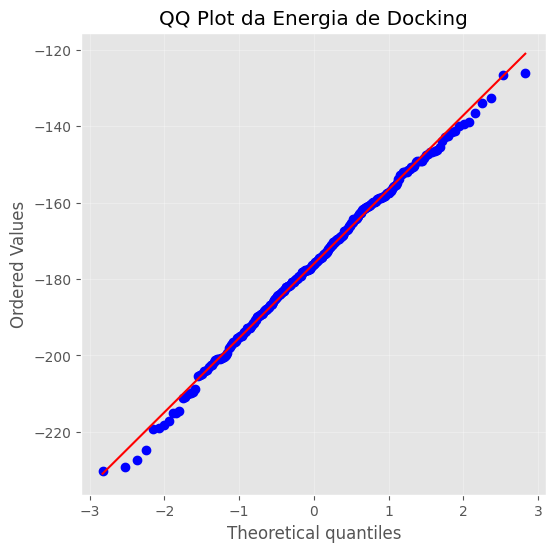

In [55]:
from scipy import stats

# ============================================================
# QQ Plot
# ============================================================

plt.figure(figsize=(6,6))

stats.probplot(
    df["best_docking_score"],
    dist="norm",
    plot=plt
)

plt.title("QQ Plot da Energia de Docking")

plt.grid(alpha=0.3)

plt.show()

Se os pontos ficarem próximos da reta,

a distribuição é aproximadamente normal.

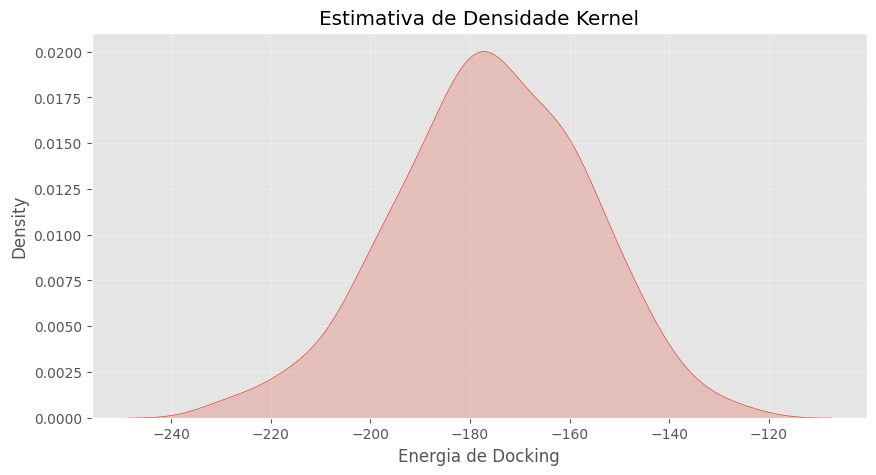

In [56]:
# ============================================================
# KDE
# ============================================================

plt.figure(figsize=(10,5))

sns.kdeplot(
    data=df,
    x="best_docking_score",
    fill=True
)

plt.title("Estimativa de Densidade Kernel")

plt.xlabel("Energia de Docking")

plt.grid(alpha=0.3)

plt.show()

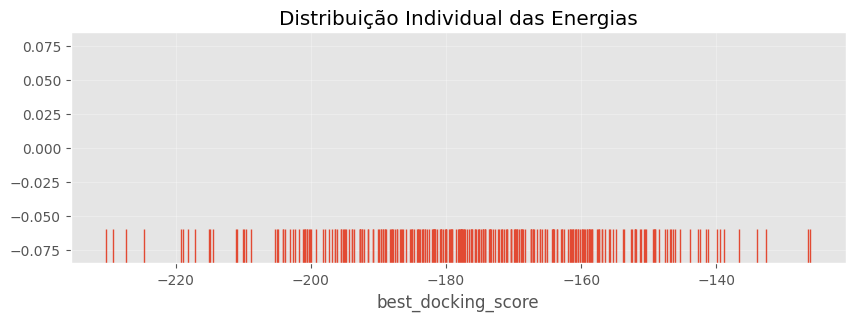

In [57]:
# ============================================================
# Rug Plot
# ============================================================

plt.figure(figsize=(10,3))

sns.rugplot(
    x=df["best_docking_score"],
    height=0.15
)

plt.title("Distribuição Individual das Energias")

plt.grid(alpha=0.3)

plt.show()

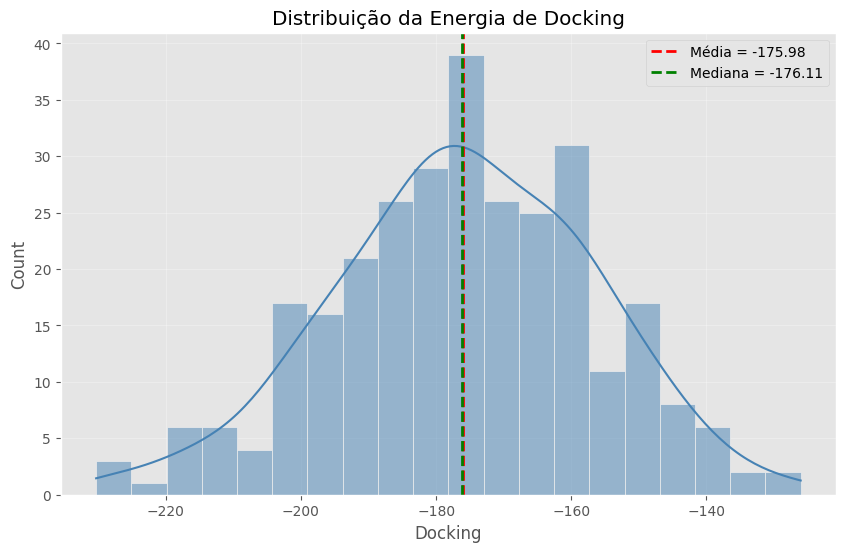

In [58]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["best_docking_score"],
    bins=20,
    kde=True,
    color="steelblue"
)

plt.axvline(
    df["best_docking_score"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Média = {df['best_docking_score'].mean():.2f}"
)

plt.axvline(
    df["best_docking_score"].median(),
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Mediana = {df['best_docking_score'].median():.2f}"
)

plt.legend()

plt.title("Distribuição da Energia de Docking")

plt.xlabel("Docking")

plt.grid(alpha=0.3)

plt.show()

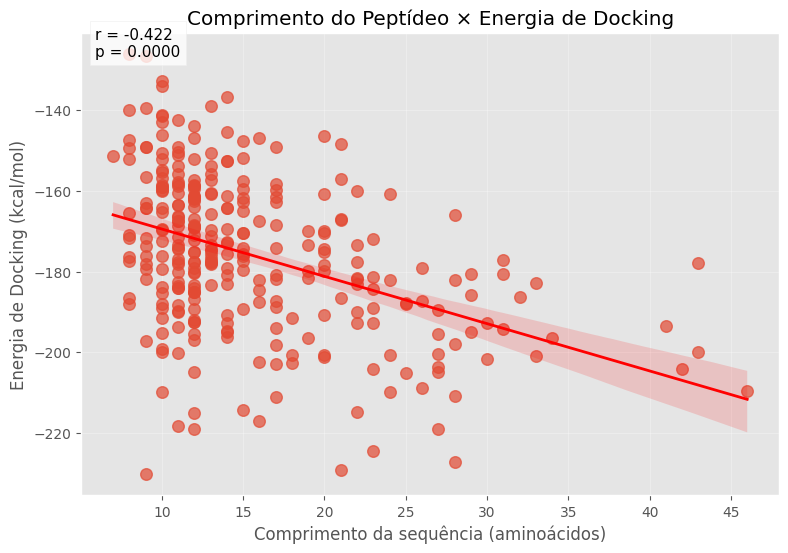

In [59]:
# ============================================================
# Scatter Plot com linha de regressão
# ============================================================

from scipy.stats import pearsonr

# Calcula o coeficiente de correlação de Pearson
r, p = pearsonr(df["length"], df["best_docking_score"])

plt.figure(figsize=(9,6))

sns.regplot(
    data=df,
    x="length",
    y="best_docking_score",
    ci=95,                     # intervalo de confiança da regressão
    scatter_kws={
        "s":70,
        "alpha":0.7
    },
    line_kws={
        "color":"red",
        "linewidth":2
    }
)

plt.title("Comprimento do Peptídeo × Energia de Docking")
plt.xlabel("Comprimento da sequência (aminoácidos)")
plt.ylabel("Energia de Docking (kcal/mol)")

plt.text(
    0.02,
    0.95,
    f"r = {r:.3f}\np = {p:.4f}",
    transform=plt.gca().transAxes,
    fontsize=11,
    bbox=dict(facecolor="white", alpha=0.8)
)

plt.grid(alpha=0.3)

plt.show()

### Relação entre comprimento e energia de docking

O gráfico de dispersão com linha de regressão permite avaliar visualmente a existência de uma relação linear entre o comprimento dos peptídeos e sua energia de docking.

Além da linha de regressão, foi calculado o coeficiente de correlação de Pearson (*r*), que mede a intensidade e a direção da associação linear entre as duas variáveis.

- valores de **r** próximos de **1** indicam forte correlação positiva;
- valores próximos de **−1** indicam forte correlação negativa;
- valores próximos de **0** sugerem ausência de relação linear.

O valor de *p* informa se a correlação observada é estatisticamente significativa.

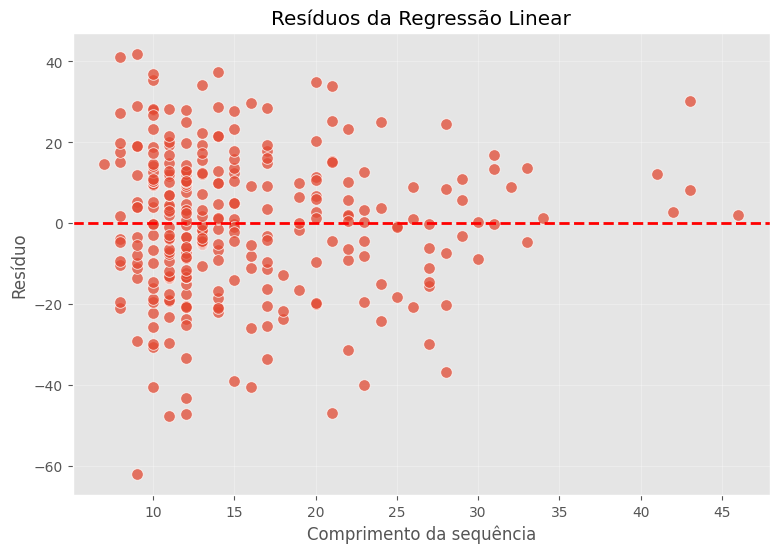

In [60]:
# ============================================================
# Gráfico de resíduos
# ============================================================

from sklearn.linear_model import LinearRegression

X = df[["length"]]
y = df["best_docking_score"]

modelo = LinearRegression()
modelo.fit(X, y)

pred = modelo.predict(X)

residuos = y - pred

plt.figure(figsize=(9,6))

sns.scatterplot(
    x=df["length"],
    y=residuos,
    s=70,
    alpha=0.75
)

plt.axhline(
    0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.title("Resíduos da Regressão Linear")
plt.xlabel("Comprimento da sequência")
plt.ylabel("Resíduo")

plt.grid(alpha=0.3)

plt.show()

### Análise dos resíduos

O gráfico de resíduos mostra a diferença entre os valores observados da energia de docking e os valores estimados por um modelo de regressão linear simples utilizando apenas o comprimento da sequência.

Idealmente, os resíduos devem estar distribuídos aleatoriamente em torno da linha horizontal correspondente ao valor zero.

Esse comportamento indica que:

- não existe tendência sistemática não explicada pelo modelo;
- a variância dos erros permanece aproximadamente constante (homocedasticidade);
- um modelo linear pode ser uma aproximação razoável.

Por outro lado, padrões como curvaturas, agrupamentos ou formato de funil sugerem que o comprimento da sequência, isoladamente, não é suficiente para explicar a energia de docking, justificando a necessidade de utilizar descritores mais ricos (AAC, AAL, CKSNAP e CKSAAGP) nas próximas etapas do projeto.

## Frequência global dos aminoácidos

Embora os modelos de Aprendizado de Máquina utilizem descritores derivados das sequências, é interessante conhecer inicialmente quais aminoácidos aparecem com maior frequência na base de dados.

Nesta análise todas as sequências são percorridas e contabiliza-se o número total de ocorrências de cada aminoácido.

Essa informação fornece uma primeira caracterização bioquímica do conjunto de dados.

In [63]:
# ============================================================
# Frequência global dos aminoácidos
# ============================================================

from collections import Counter

contador = Counter()

for seq in df["peptide_fasta_sequence"]:
    contador.update(seq)

freq_df = (
    pd.DataFrame(
        contador.items(),
        columns=["Aminoácido","Frequência"]
    )
    .sort_values("Frequência", ascending=False)
    .reset_index(drop=True)
)

total = freq_df["Frequência"].sum()

freq_df["Percentual"] = (
    100 *
    freq_df["Frequência"] /
    total
)

freq_df

,Aminoácido,Frequência,Percentual
0,P,945,20.521173
1,G,601,13.051031
2,S,402,8.729642
3,A,348,7.557003
4,L,276,5.993485
5,V,203,4.408252
6,K,197,4.277959
7,T,194,4.212812
8,R,182,3.952226
9,E,181,3.930510


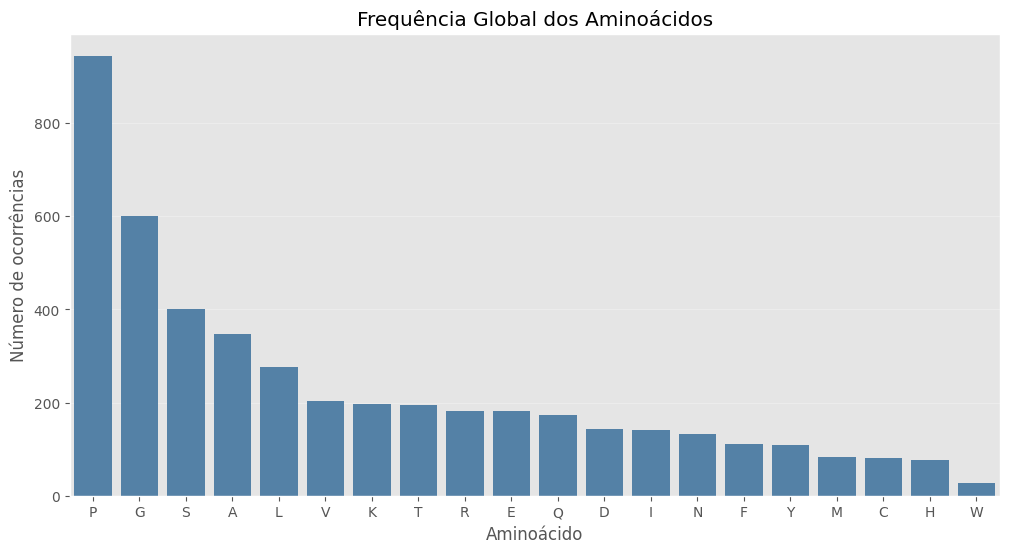

In [64]:
# ============================================================
# Frequência dos aminoácidos
# ============================================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=freq_df,
    x="Aminoácido",
    y="Frequência",
    color="steelblue"
)

plt.title("Frequência Global dos Aminoácidos")

plt.xlabel("Aminoácido")

plt.ylabel("Número de ocorrências")

plt.grid(axis="y", alpha=0.3)

plt.show()

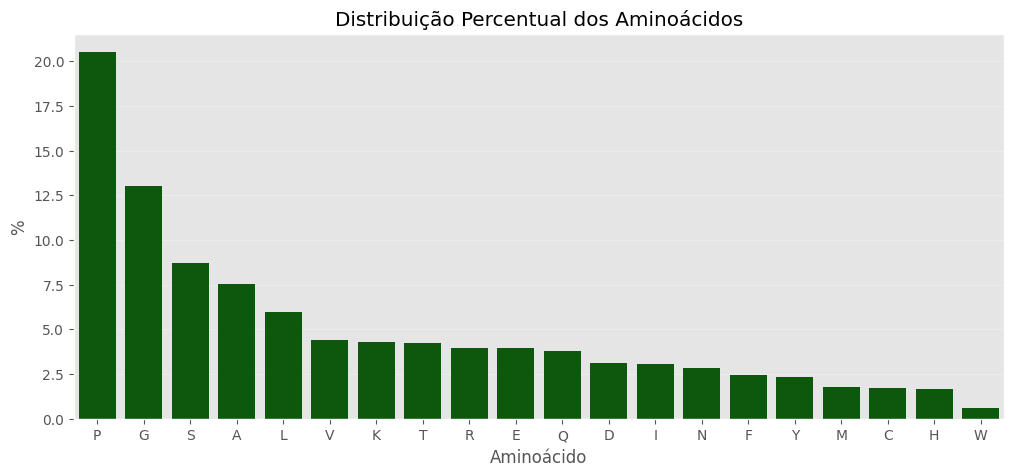

In [66]:
plt.figure(figsize=(12,5))

sns.barplot(
    data=freq_df,
    x="Aminoácido",
    y="Percentual",
    color="darkgreen"
)

plt.title("Distribuição Percentual dos Aminoácidos")

plt.ylabel("%")

plt.grid(axis="y", alpha=0.3)

plt.show()

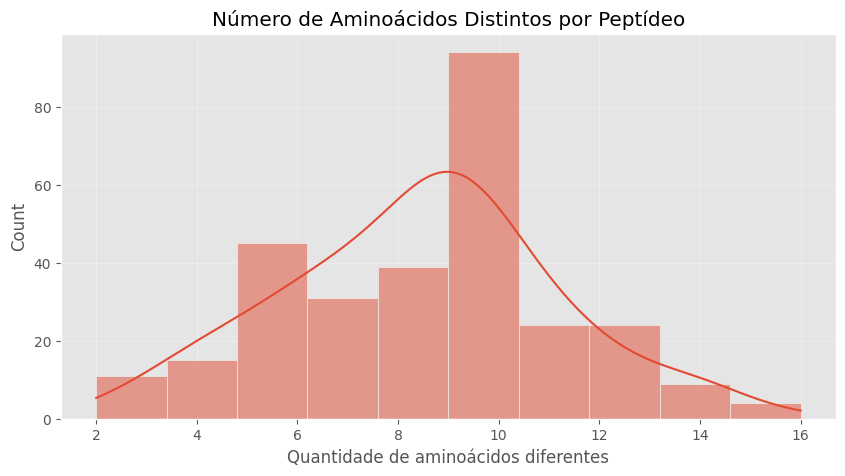

In [68]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="unique_aminoacids",
    bins=10,
    kde=True
)

plt.title("Número de Aminoácidos Distintos por Peptídeo")

plt.xlabel("Quantidade de aminoácidos diferentes")

plt.grid(alpha=0.3)

plt.show()

## Conclusões

A análise exploratória mostrou que:

- o conjunto de dados possui 296 peptídeos;

- não existem valores ausentes;

- há apenas uma sequência duplicada;

- os comprimentos variam entre 7 e 46 resíduos;

- a energia de docking apresenta distribuição aproximadamente contínua;

- existe grande variabilidade entre os peptídeos;

- as sequências apresentam composição heterogênea de aminoácidos.

Esses resultados indicam que a base possui qualidade suficiente para as próximas etapas do processo de mineração de dados especialmente para a construção dos descritores AAC, AAL, CKSNAP e CKSAAGP.